# 09 Employee Analytics and Staffing Prediction

## Objective
Cluster employees by performance signals and estimate staffing needs from sales, fully inside this notebook.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import plotly.express as px
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.metrics import silhouette_score

candidate_roots = [Path.cwd(), Path.cwd().parent]
project_root = next((p for p in candidate_roots if (p / 'data').exists()), None)
if project_root is None:
    raise FileNotFoundError('Could not locate data folder. Run from project root or notebooks folder.')

data_dir = project_root / 'data'
print(f'Project Root: {project_root}')
print(f'Data Directory: {data_dir}')

Project Root: D:\projects\ai-ml-projects\PharmaEase_correct\pharma_ease_ai
Data Directory: D:\projects\ai-ml-projects\PharmaEase_correct\pharma_ease_ai\data


In [2]:
employees = pd.read_csv(data_dir / 'employees.csv')
sales = pd.read_csv(data_dir / 'sales.csv')
sales['date'] = pd.to_datetime(sales['date'], errors='coerce')
sales['revenue'] = sales['quantity'] * sales['price']

print('Loaded datasets:')
print({'employees': employees.shape, 'sales': sales.shape})

Loaded datasets:
{'employees': (1200, 5), 'sales': (2000, 7)}


In [3]:
features = employees[['performance_score', 'attendance', 'workload']]
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
employees['employee_segment'] = kmeans.fit_predict(features)

sil = silhouette_score(features, employees['employee_segment']) if len(employees) > 3 else 0.0
print(f'Silhouette score: {sil:.3f}')
print('Segment counts:')
print(employees['employee_segment'].value_counts().sort_index())

Silhouette score: 0.340
Segment counts:
employee_segment
0    329
1    551
2    320
Name: count, dtype: int64


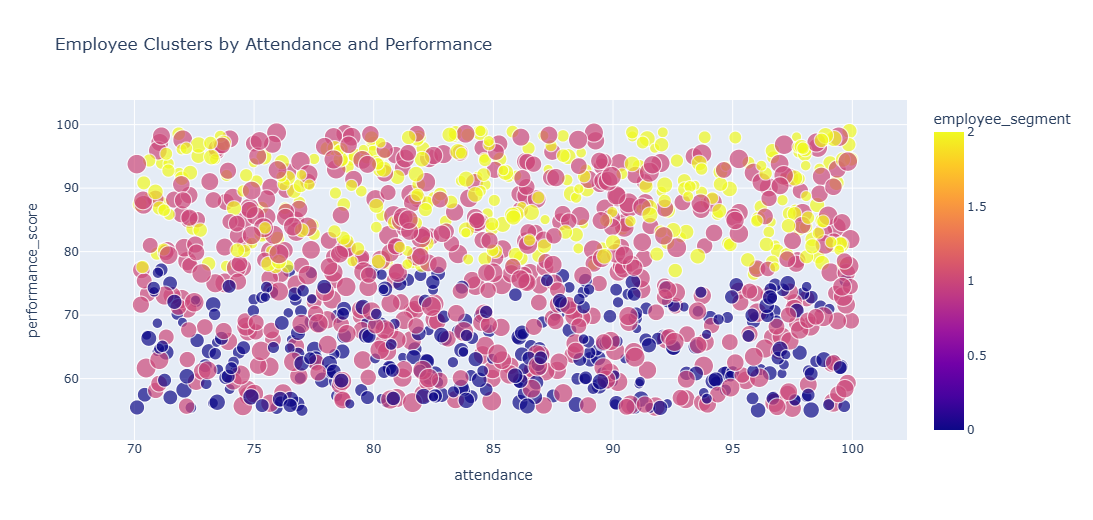

In [4]:
fig = px.scatter(
    employees,
    x='attendance',
    y='performance_score',
    size='workload',
    color='employee_segment',
    title='Employee Clusters by Attendance and Performance'
)
fig.update_layout(height=520)
fig.show()

In [5]:
monthly_sales = (
    sales.assign(month=sales['date'].dt.to_period('M').astype(str))
    .groupby('month', as_index=False)['revenue']
    .sum()
)

base_staff = max(3, int(np.ceil(len(employees) * 0.2)))
monthly_sales['required_staff'] = (
    base_staff + (monthly_sales['revenue'] / monthly_sales['revenue'].max()) * 8
).round().astype(int)

reg = LinearRegression()
reg.fit(monthly_sales[['revenue']], monthly_sales['required_staff'])
monthly_sales['predicted_required_staff'] = reg.predict(monthly_sales[['revenue']]).round().astype(int)

display(monthly_sales.head())

,month,revenue,required_staff,predicted_required_staff
0,2023-01,22329.80,247,247
1,2023-02,19446.12,246,246
2,2023-03,22349.47,247,247
3,2023-04,18125.11,246,246
4,2023-05,15661.59,245,245


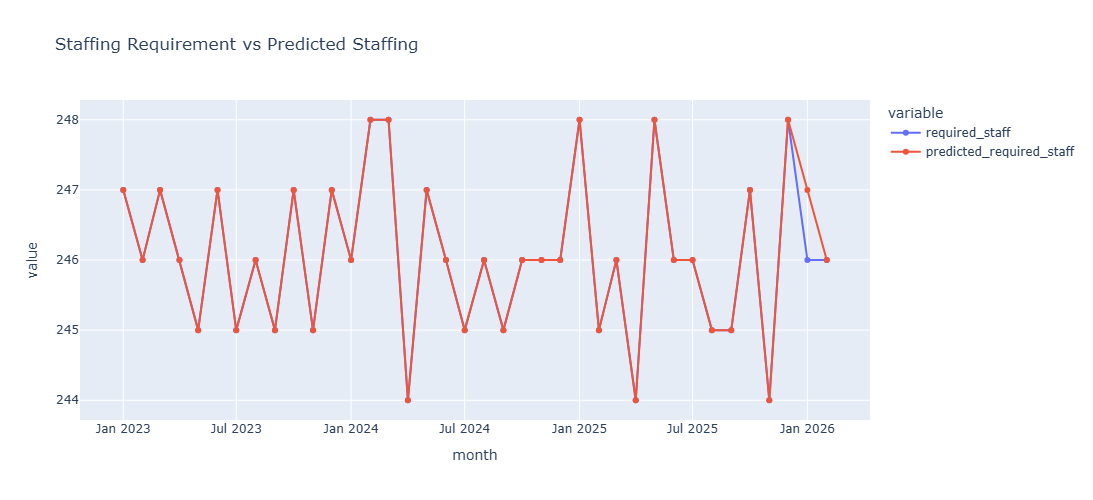

In [6]:
fig = px.line(
    monthly_sales,
    x='month',
    y=['required_staff', 'predicted_required_staff'],
    title='Staffing Requirement vs Predicted Staffing',
    markers=True
)
fig.update_layout(hovermode='x unified', height=500)
fig.show()

## Recommendations

- Prioritize retention and leadership pathways for top-performing segments.
- Use predicted staffing to plan shift allocation before peak months.
- Monitor attendance-workload imbalance to prevent burnout.
- Use segment-level coaching for performance uplift.